In [1]:
!pip install influxdb3-python scikit-learn pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.6/218.6 kB 7.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import requests
import json

# ═══════════════════════════════════════
# ÉTAPE 1 — Récupérer les données depuis InfluxDB
# ═══════════════════════════════════════

TOKEN = "apiv3_FIMhMrTroPkUhl_BbczpOUSM2_5hyXqfyd8njn7aNSnj6qnfNE3EQIEzdDm24kd10sYUcsmRJyTMBi2shGJUQQ"
URL = "http://10.142.14.9:8181/api/v3/query_sql"

# Remplace YOUR_PC_IP par ton IP local
# Pour trouver ton IP : ouvre CMD et tape ipconfig → cherche "Adresse IPv4"

headers = {
    "Authorization": f"Bearer {TOKEN}",
    "Content-Type": "application/json"
}

query = {
    "db": "lafarge",
    "q": "SELECT time, temperature, vibration FROM capteurs_moteur ORDER BY time DESC LIMIT 200"
}

response = requests.post(URL, headers=headers, json=query)
print("Status:", response.status_code)
print("Data:", response.text[:500])

ConnectTimeout: HTTPConnectionPool(host='10.142.14.9', port=8181): Max retries exceeded with url: /api/v3/query_sql (Caused by ConnectTimeoutError(<urllib3.connection.HTTPConnection object at 0x7c4f85dee120>, 'Connection to 10.142.14.9 timed out. (connect timeout=None)'))

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from datetime import datetime, timedelta

# ═══════════════════════════════════════
# ÉTAPE 1 — Simuler les données capteurs
# ═══════════════════════════════════════

np.random.seed(42)
n_normal = 200
n_anomalie = 20

# Données normales — moteur en bon état
temps_normal = [datetime.now() - timedelta(seconds=i*5) for i in range(n_normal)]
temp_normale = np.random.normal(24, 0.5, n_normal)
vibr_normale = np.random.normal(9.81, 0.2, n_normal)

# Données anomalies — roulement dégradé
temps_anomalie = [datetime.now() - timedelta(seconds=i*5) for i in range(n_anomalie)]
temp_anomalie = np.random.normal(45, 3, n_anomalie)
vibr_anomalie = np.random.normal(15, 2, n_anomalie)

# Combiner les données
df_normal = pd.DataFrame({
    'time': temps_normal,
    'temperature': temp_normale,
    'vibration': vibr_normale,
    'type': 'normal'
})

df_anomalie = pd.DataFrame({
    'time': temps_anomalie,
    'temperature': temp_anomalie,
    'vibration': vibr_anomalie,
    'type': 'anomalie'
})

df = pd.concat([df_normal, df_anomalie], ignore_index=True)
df = df.sample(frac=1).reset_index(drop=True)  # Mélange

print(f"Total données : {len(df)}")
print(f"Normales : {len(df_normal)}")
print(f"Anomalies : {len(df_anomalie)}")
print(df.head(10))

Total données : 220
Normales : 200
Anomalies : 20
                        time  temperature  vibration      type
0 2026-06-10 22:28:38.122554    48.537892  11.593235  anomalie
1 2026-06-10 22:19:03.121416    24.236796   9.674568    normal
2 2026-06-10 22:16:48.121455    23.512659   9.913869    normal
3 2026-06-10 22:18:33.121431    23.384568   9.697255    normal
4 2026-06-10 22:28:53.121261    23.718856   9.961794    normal
5 2026-06-10 22:25:23.121309    23.845394   9.668466    normal
6 2026-06-10 22:15:48.121469    23.961449  10.100229    normal
7 2026-06-10 22:20:13.121400    24.375967   9.783971    normal
8 2026-06-10 22:23:38.121353    24.045880   9.823960    normal
9 2026-06-10 22:29:08.122547    40.397657  14.461186  anomalie


In [4]:
# ═══════════════════════════════════════
# ÉTAPE 2 — Isolation Forest
# ═══════════════════════════════════════

# Features pour le modèle
X = df[['temperature', 'vibration']].values

# Entraîne le modèle
model = IsolationForest(
    contamination=0.1,  # 10% de données anormales attendues
    random_state=42,
    n_estimators=100
)
model.fit(X)

# Prédictions : -1 = anomalie, 1 = normal
df['prediction'] = model.predict(X)
df['score_anomalie'] = model.score_samples(X)

# Convertit en pourcentage lisible
df['score_pct'] = ((df['score_anomalie'] - df['score_anomalie'].min()) /
                   (df['score_anomalie'].max() - df['score_anomalie'].min()) * 100).round(1)

# Résultats
anomalies_detectees = df[df['prediction'] == -1]
print(f"Anomalies détectées : {len(anomalies_detectees)}")
print(f"Précision détection : {len(anomalies_detectees[anomalies_detectees['type']=='anomalie'])} / {len(df_anomalie)} anomalies réelles trouvées")
print("\nExemples d'anomalies détectées :")
print(anomalies_detectees[['time','temperature','vibration','score_pct']].head(5))

Anomalies détectées : 22
Précision détection : 19 / 20 anomalies réelles trouvées

Exemples d'anomalies détectées :
                         time  temperature  vibration  score_pct
0  2026-06-10 22:28:38.122554    48.537892  11.593235       14.4
9  2026-06-10 22:29:08.122547    40.397657  14.461186       19.4
13 2026-06-10 22:29:38.122540    41.797139  13.070153       18.4
31 2026-06-10 22:29:03.122548    48.833030  16.435085       14.8
33 2026-06-10 22:29:13.122546    41.626074  10.921536       11.9


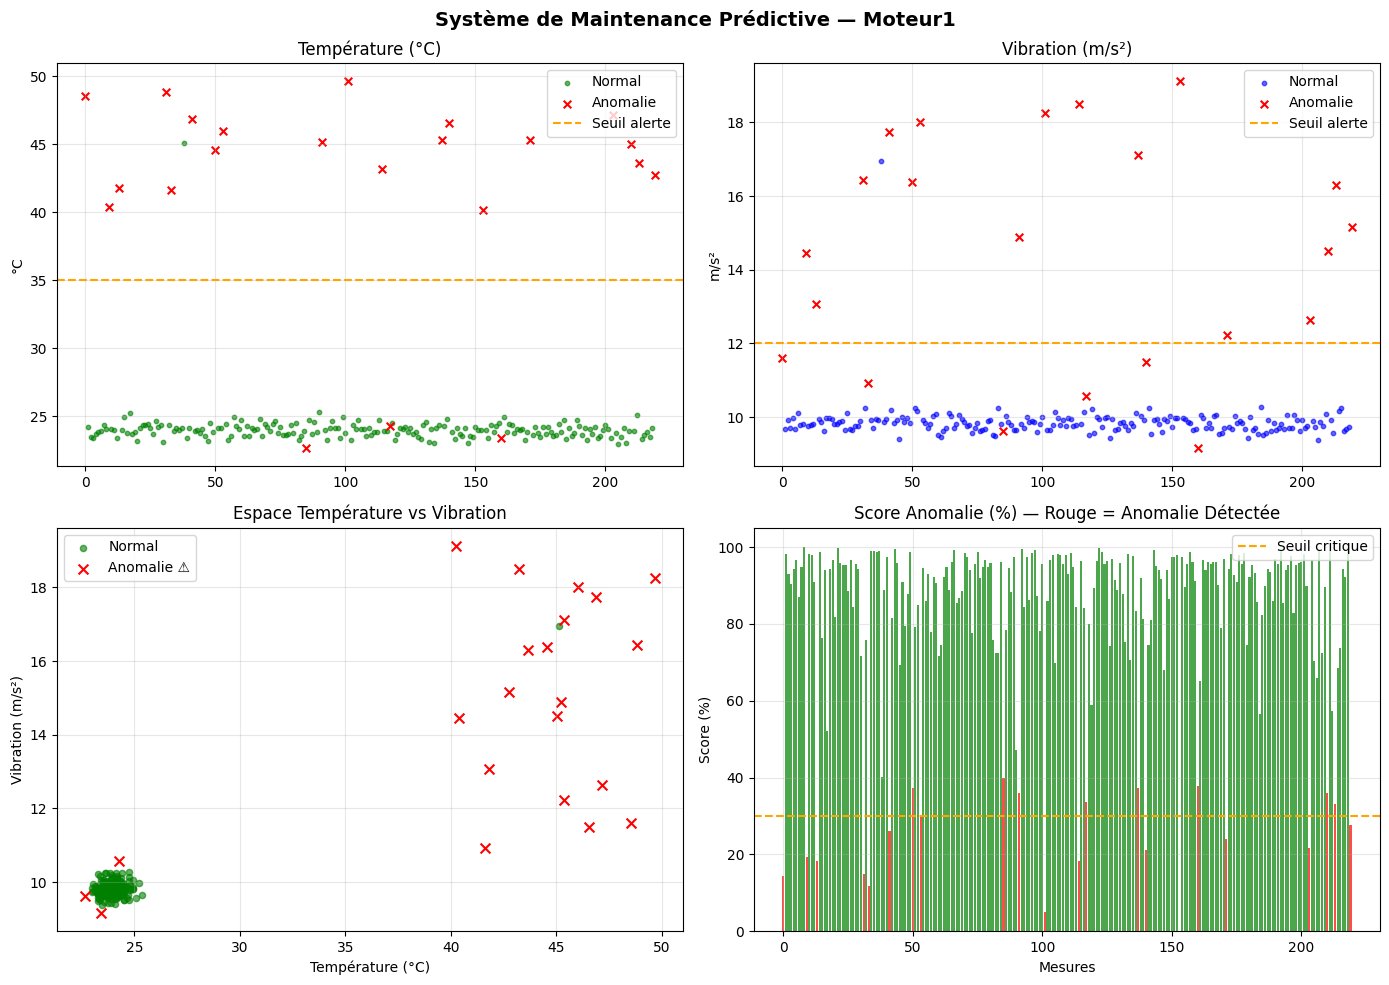

✅ Graphe sauvegardé : maintenance_predictive.png


In [6]:
# ═══════════════════════════════════════
# ÉTAPE 3 — Visualisation professionnelle
# ═══════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Système de Maintenance Prédictive — Moteur1',
             fontsize=14, fontweight='bold')

# Graphe 1 — Température dans le temps
ax1 = axes[0, 0]
normaux = df[df['prediction'] == 1]
anomalies = df[df['prediction'] == -1]
ax1.scatter(normaux.index, normaux['temperature'], c='green', s=10, label='Normal', alpha=0.6)
ax1.scatter(anomalies.index, anomalies['temperature'], c='red', s=30, label='Anomalie', marker='x')
ax1.axhline(y=35, color='orange', linestyle='--', label='Seuil alerte')
ax1.set_title('Température (°C)')
ax1.set_ylabel('°C')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Graphe 2 — Vibration dans le temps
ax2 = axes[0, 1]
ax2.scatter(normaux.index, normaux['vibration'], c='blue', s=10, label='Normal', alpha=0.6)
ax2.scatter(anomalies.index, anomalies['vibration'], c='red', s=30, label='Anomalie', marker='x')
ax2.axhline(y=12, color='orange', linestyle='--', label='Seuil alerte')
ax2.set_title('Vibration (m/s²)')
ax2.set_ylabel('m/s²')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Graphe 3 — Espace température/vibration
ax3 = axes[1, 0]
ax3.scatter(normaux['temperature'], normaux['vibration'], c='green', s=20, label='Normal', alpha=0.6)
ax3.scatter(anomalies['temperature'], anomalies['vibration'], c='red', s=50, label='Anomalie ⚠️', marker='x')
ax3.set_title('Espace Température vs Vibration')
ax3.set_xlabel('Température (°C)')
ax3.set_ylabel('Vibration (m/s²)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Graphe 4 — Score d'anomalie
ax4 = axes[1, 1]
colors = ['red' if p == -1 else 'green' for p in df['prediction']]
ax4.bar(range(len(df)), df['score_pct'], color=colors, alpha=0.7)
ax4.set_title('Score Anomalie (%) — Rouge = Anomalie Détectée')
ax4.set_xlabel('Mesures')
ax4.set_ylabel('Score (%)')
ax4.axhline(y=30, color='orange', linestyle='--', label='Seuil critique')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('maintenance_predictive.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphe sauvegardé : maintenance_predictive.png")